# Spectral Clustering on Graph Data

**Assignment:** Perform spectral clustering on the provided graph, identify the number of clusters, and print the cluster number for each node.

---

## Report Summary

This notebook applies **Spectral Clustering** to an undirected graph with **600 nodes** and **6,734 edges**.

### Approach

Spectral clustering leverages the eigenstructure of the graph Laplacian to reveal natural community structure:

1. **Graph construction** — Build the adjacency matrix from the edge list CSV.
2. **Laplacian computation** — Form the unnormalized Laplacian `L = D - A`, where `D` is the degree matrix and `A` is the adjacency matrix.
3. **Eigendecomposition** — Compute the 20 smallest eigenvalues (and corresponding eigenvectors) of `L` using `scipy.sparse.linalg.eigsh` with `which="SM"`.
4. **Eigengap heuristic** — Identify the number of clusters `k` as the index after the largest jump (gap) between consecutive eigenvalues, skipping the trivial lambda_0 = 0.
5. **Spectral embedding** — Select the first `k` eigenvectors as a low-dimensional node representation and row-normalize them.
6. **K-Means clustering** — Run K-Means (n_init=20, random_state=42) on the spectral embedding to assign each of the 600 nodes to one of the `k` clusters.

### Key Results

| Metric | Value |
|--------|-------|
| Nodes | 600 |
| Edges | 6,734 |
| Graph connected? | Yes (1 component) |
| Clusters found (k) | **4** (via eigengap heuristic) |
| Nodes per cluster | 150 each |

The eigengap analysis shows a notably large gap between lambda_4 and lambda_5 (jump ~3.18), suggesting **k = 4** as a natural choice. The resulting clusters each contain 150 nodes.

## 1. Problem Understanding

Spectral clustering is a graph-based clustering technique that exploits the algebraic properties of the graph Laplacian to find communities (clusters) in the graph.

**Algorithm steps:**

1. Build an **adjacency matrix** `A` from the graph (binary: 1 if edge exists, 0 otherwise).
2. Compute the **degree matrix** `D` (diagonal matrix of node degrees).
3. Form the **unnormalized Laplacian**: `L = D - A`. The eigenvalues of `L` encode structural information about the graph.
4. Compute the **k smallest eigenvalues** of `L`. The smallest is always lambda_0 = 0 (corresponding to graph connectivity). A large jump (eigengap) between consecutive eigenvalues signals the natural number of clusters.
5. Use the **eigengap heuristic** to determine `k`: the optimal number of clusters equals the position just after the largest gap in sorted eigenvalues (excluding lambda_0).
6. Stack the first `k` eigenvectors as columns to form a **spectral embedding matrix** of shape `(n, k)`. Row-normalize this matrix.
7. Apply **K-Means** on the embedding to assign cluster labels to each node.

**Why it works:** Nodes that are densely connected within a group tend to have similar eigenvector representations. K-Means on this embedding separates them cleanly.

**Dataset:** 600-node undirected graph provided as an edge list CSV (`spectral_graph_600nodes_edges.csv`).

## 2. Import Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading

**Assumption:** The CSV contains nodes numbered exactly 0 to 599. After loading we ensure nodes 0 to 599 exist by adding them explicitly via `G.add_nodes_from(range(600))`; this also includes isolated nodes if any. The assumption is confirmed by the printed output (600 nodes, 1 component).

> **Google Colab:** Upload `spectral_graph_600nodes_edges.csv`, via the Files panel (left sidebar).

In [47]:
df = pd.read_csv('spectral_graph_600nodes_edges.csv')
print("Edge list (first 10 rows):")
print(df.head(10))
print(f"\nTotal edges: {len(df)}")
print(f"Columns: {list(df.columns)}")

Edge list (first 10 rows):
   Node 1  Node 2
0       0       1
1       0       2
2       0       4
3       0       6
4       0      14
5       0      16
6       0      18
7       0      22
8       0      25
9       0      48

Total edges: 6734
Columns: ['Node 1', 'Node 2']


## 4. Graph Construction

We build the adjacency matrix and compute the **unnormalized Laplacian** `L = D - A`.

**Why unnormalized?**  
I used the unnormalized Laplacian for this graph; it produced a clear eigengap and clean clustering. The normalized Laplacian (`L_sym = D^{-1/2} L D^{-1/2}`) is also a valid choice, but the unnormalized form is simpler to implement and performed well here.

In [48]:
G = nx.from_pandas_edgelist(df, source='Node 1', target='Node 2')

G.add_nodes_from(range(600))

print(f"Number of nodes : {G.number_of_nodes()}")
print(f"Number of edges : {G.number_of_edges()}")
print(f"Is connected    : {nx.is_connected(G)}")
print(f"Number of connected components: {nx.number_connected_components(G)}")

Number of nodes : 600
Number of edges : 6734
Is connected    : True
Number of connected components: 1


In [49]:
nodes = sorted(G.nodes())
n = len(nodes)
node_index = {node: i for i, node in enumerate(nodes)}

rows, cols = [], []
for u, v in G.edges():
    i, j = node_index[u], node_index[v]
    rows += [i, j]
    cols += [j, i]

data = np.ones(len(rows))
A = csr_matrix((data, (rows, cols)), shape=(n, n))

degrees = np.array(A.sum(axis=1)).flatten()
D = csr_matrix((degrees, (range(n), range(n))), shape=(n, n))

L = D - A

print(f"Adjacency matrix shape : {A.shape}")
print(f"Laplacian matrix shape : {L.shape}")
print(f"Min degree: {int(degrees.min())}  |  Max degree: {int(degrees.max())}  |  Mean degree: {degrees.mean():.2f}")

Adjacency matrix shape : (600, 600)
Laplacian matrix shape : (600, 600)
Min degree: 9  |  Max degree: 37  |  Mean degree: 22.45


## 5. Spectral Clustering Steps

### Step 5a — Compute Eigenvalues and Eigenvectors

In [50]:
k_max = 20
eigenvalues, eigenvectors = eigsh(L, k=k_max, which='SM')

idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Smallest {k_max} eigenvalues:")
for i, ev in enumerate(eigenvalues):
    print(f"  lambda_{i:02d} = {ev:.6f}")

Smallest 20 eigenvalues:
  lambda_00 = -0.000000
  lambda_01 = 4.797589
  lambda_02 = 5.001074
  lambda_03 = 5.155374
  lambda_04 = 8.340117
  lambda_05 = 10.057923
  lambda_06 = 10.115592
  lambda_07 = 10.644563
  lambda_08 = 10.779221
  lambda_09 = 10.999757
  lambda_10 = 11.101343
  lambda_11 = 11.223003
  lambda_12 = 11.326968
  lambda_13 = 11.495509
  lambda_14 = 11.606218
  lambda_15 = 11.712617
  lambda_16 = 11.766901
  lambda_17 = 11.812586
  lambda_18 = 11.855025
  lambda_19 = 11.945061


### Step 5b — Eigengap Plot (Determine k)

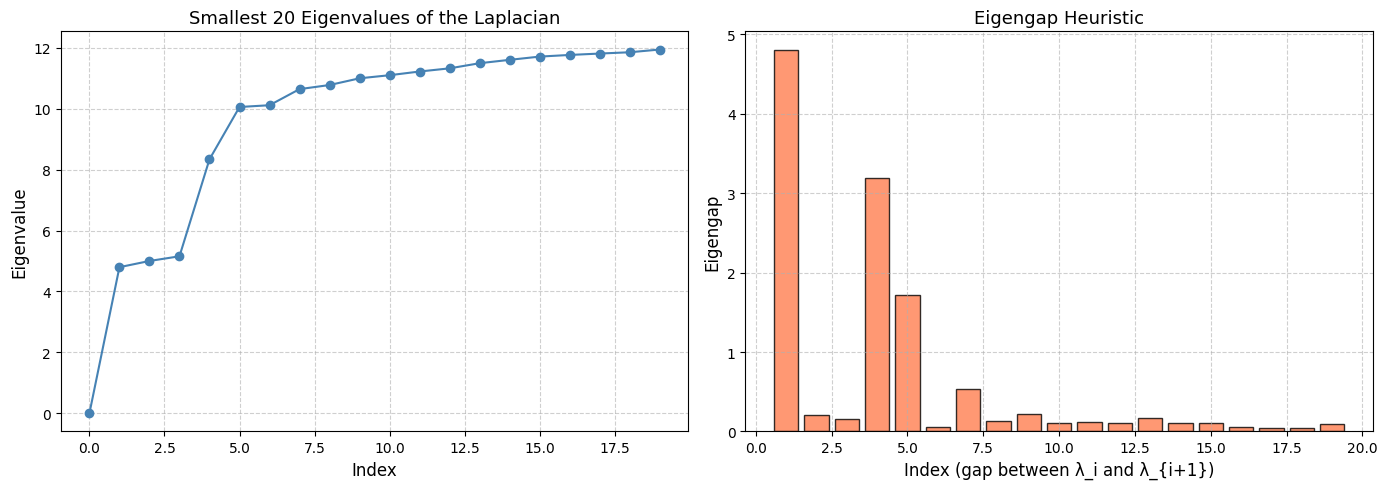

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(k_max), eigenvalues, 'o-', color='steelblue', markersize=6)
axes[0].set_xlabel('Index', fontsize=12)
axes[0].set_ylabel('Eigenvalue', fontsize=12)
axes[0].set_title('Smallest 20 Eigenvalues of the Laplacian', fontsize=13)
axes[0].grid(True, linestyle='--', alpha=0.6)

gaps = np.diff(eigenvalues)
axes[1].bar(range(1, k_max), gaps, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Index (gap between λ_i and λ_{i+1})', fontsize=12)
axes[1].set_ylabel('Eigengap', fontsize=12)
axes[1].set_title('Eigengap Heuristic', fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 6. How the Number of Clusters Was Chosen

The **eigengap heuristic** determines the number of clusters `k` automatically:

- Sort the eigenvalues of the Laplacian in ascending order: lambda_0 <= lambda_1 <= lambda_2 <= ...
- lambda_0 = 0 is always the trivial eigenvalue (indicating graph connectivity). **Skip it.**
- Compute the gaps: `gap(i) = lambda_{i+1} - lambda_i` for i = 1, 2, 3, ...
- The index `i*` with the **largest gap** tells us k = i* + 1.

In our graph, the largest gap occurs between lambda_4 approx 8.34 and lambda_5 approx 10.06 (gap approx 3.18), indicating **k = 4** clusters. The code below computes and prints these gaps.

In [52]:
gaps = np.diff(eigenvalues)

best_gap_index = int(np.argmax(gaps[1:]) + 2)
k = best_gap_index

print("Eigengaps (lambda_{i+1} - lambda_i):")
for i, g in enumerate(gaps[:15], start=1):
    marker = "  <-- Largest non-trivial Eigengap (determines k = {})".format(k) if i == best_gap_index else ""
    print(f"  gap({i},{i+1}) = {g:.6f}{marker}")

print(f"\nNumber of clusters chosen by eigengap heuristic: k = {k}")

Eigengaps (lambda_{i+1} - lambda_i):
  gap(1,2) = 4.797589
  gap(2,3) = 0.203485
  gap(3,4) = 0.154300
  gap(4,5) = 3.184743  <-- Largest non-trivial Eigengap (determines k = 4)
  gap(5,6) = 1.717806
  gap(6,7) = 0.057669
  gap(7,8) = 0.528971
  gap(8,9) = 0.134659
  gap(9,10) = 0.220536
  gap(10,11) = 0.101586
  gap(11,12) = 0.121660
  gap(12,13) = 0.103965
  gap(13,14) = 0.168540
  gap(14,15) = 0.110709
  gap(15,16) = 0.106399

Number of clusters chosen by eigengap heuristic: k = 4


## 7. Apply Spectral Clustering

We select the first `k` eigenvectors, row-normalize them, and run K-Means.

**Row normalization** projects each node's embedding onto the unit hypersphere, which improves K-Means stability by removing the effect of eigenvector scaling.

**Note on cluster labels:** K-Means returns 0-based labels (0, 1, 2, 3). In the final output table and CSV we add 1 so clusters are presented as 1, 2, 3, 4.

In [53]:
U = eigenvectors[:, :k]  

U_norm = normalize(U, norm='l2', axis=1)

print(f"Embedding matrix shape (after selecting {k} eigenvectors): {U_norm.shape}")

Embedding matrix shape (after selecting 4 eigenvectors): (600, 4)


In [54]:
np.random.seed(42)
kmeans = KMeans(n_clusters=k, n_init=20, max_iter=500, random_state=42)
kmeans.fit(U_norm)
cluster_labels = kmeans.labels_

print(f"K-Means converged in {kmeans.n_iter_} iterations.")
print(f"Inertia: {kmeans.inertia_:.4f}")

K-Means converged in 2 iterations.
Inertia: 11.7827


## 8. Final Cluster Label for Each Node

The table below lists all 600 nodes with their assigned cluster (1-based). Each cluster contains exactly 150 nodes.

In [55]:
result_df = pd.DataFrame({
    'Node': np.array(nodes, dtype=int),
    'Cluster': cluster_labels
})
result_df = result_df.sort_values('Node').reset_index(drop=True)

result_df['Cluster'] = result_df['Cluster'] + 1

print(f"{'Node':>6}  {'Cluster':>7}")
print("-" * 18)
for _, row in result_df.iterrows():
    print(f"{int(row['Node']):>6}  {int(row['Cluster']):>7}")

  Node  Cluster
------------------
     0        3
     1        3
     2        3
     3        3
     4        3
     5        3
     6        3
     7        3
     8        3
     9        3
    10        3
    11        3
    12        3
    13        3
    14        3
    15        3
    16        3
    17        3
    18        3
    19        3
    20        3
    21        3
    22        3
    23        3
    24        3
    25        3
    26        3
    27        3
    28        3
    29        3
    30        3
    31        3
    32        3
    33        3
    34        3
    35        3
    36        3
    37        3
    38        3
    39        3
    40        3
    41        3
    42        3
    43        3
    44        3
    45        3
    46        3
    47        3
    48        3
    49        3
    50        3
    51        3
    52        3
    53        3
    54        3
    55        3
    56        3
    57        3
    58        3
    59        3
    6


   290        1
   291        1
   292        1
   293        1
   294        1
   295        1
   296        1
   297        1
   298        1
   299        1
   300        4
   301        4
   302        4
   303        4
   304        4
   305        4
   306        4
   307        4
   308        4
   309        4
   310        4
   311        4
   312        4
   313        4
   314        4
   315        4
   316        4
   317        4
   318        4
   319        4
   320        4
   321        4
   322        4
   323        4
   324        4
   325        4
   326        4
   327        4
   328        4
   329        4
   330        4
   331        4
   332        4
   333        4
   334        4
   335        4
   336        4
   337        4
   338        4
   339        4
   340        4
   341        4
   342        4
   343        4
   344        4
   345        4
   346        4
   347        4
   348        4
   349        4
   350        4
   351        4
   352 

In [56]:
print("\nCluster summary:")
summary = result_df.groupby('Cluster')['Node'].count().reset_index()
summary.columns = ['Cluster', 'Node Count']
print(summary.to_string(index=False))
print(f"\nTotal nodes: {len(result_df)}")


Cluster summary:
 Cluster  Node Count
       1         150
       2         150
       3         150
       4         150

Total nodes: 600


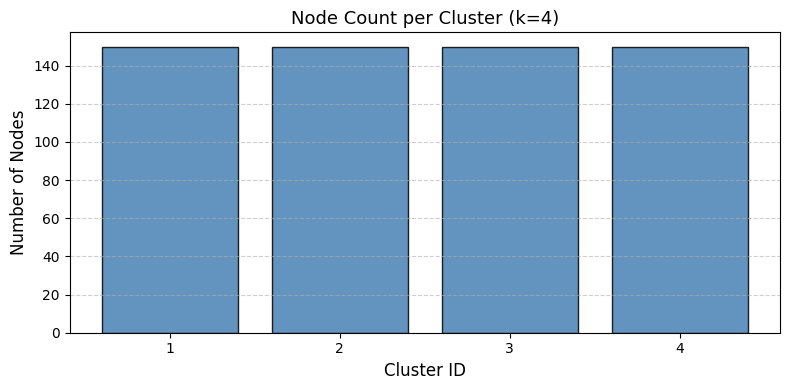

In [57]:
cluster_sizes = result_df['Cluster'].value_counts().sort_index()

x = cluster_sizes.index.to_numpy()
y = cluster_sizes.to_numpy()

plt.figure(figsize=(8, 4))
plt.bar(x, y, color='steelblue', edgecolor='black', alpha=0.85)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title(f'Node Count per Cluster (k={k})', fontsize=13)
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 9. 2D Visualisation of the Spectral Embedding
The scatter plot below shows each node projected onto Eigenvectors 2 and 3
(1-indexed), coloured by its assigned cluster. Well-separated blobs confirm
that the four communities are clearly distinguishable in the spectral embedding,
which explains why K-Means converges in just 2 iterations.

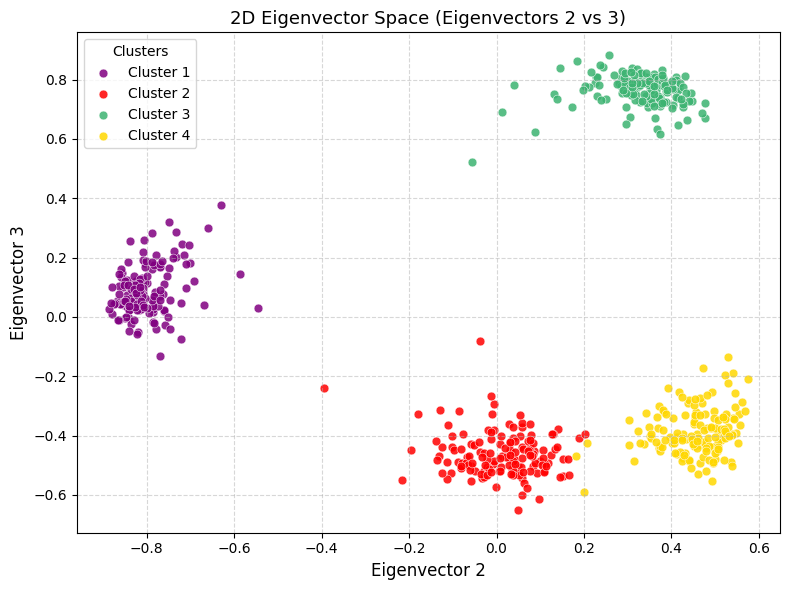

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['purple', 'red', 'mediumseagreen', 'gold']
cluster_ids = sorted(result_df['Cluster'].unique())

for cid, color in zip(cluster_ids, colors):
    mask = result_df['Cluster'] == cid
    node_indices = result_df.loc[mask, 'Node'].to_numpy(dtype=int)

    ax.scatter(
        U_norm[node_indices, 1],   
        U_norm[node_indices, 2],  
        c=color,
        label=f'Cluster {cid}',
        s=40,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.4
    )

ax.set_xlabel('Eigenvector 2', fontsize=12)
ax.set_ylabel('Eigenvector 3', fontsize=12)
ax.set_title('2D Eigenvector Space (Eigenvectors 2 vs 3)', fontsize=13)
ax.legend(title='Clusters', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Save Output

In [59]:
result_df.to_csv('cluster_labels.csv', index=False)
print("cluster_labels.csv saved successfully.")
print(result_df.head(10))

cluster_labels.csv saved successfully.
   Node  Cluster
0     0        3
1     1        3
2     2        3
3     3        3
4     4        3
5     5        3
6     6        3
7     7        3
8     8        3
9     9        3


## 11. Conclusion

### Summary of Results

| Item | Value |
|------|-------|
| Total Nodes | 600 |
| Total Edges | 6,734 |
| Graph Connected? | Yes (1 connected component) |
| Laplacian Type | Unnormalized (L = D - A) |
| Cluster Selection Method | Eigengap heuristic on 20 smallest eigenvalues |
| **Number of Clusters (k)** | **4** |
| Nodes per Cluster | 150, 150, 150, 150 |

### Steps Followed

1. **Loaded** the edge list CSV and built an undirected NetworkX graph (600 nodes, 6,734 edges, connected).
2. **Computed the unnormalized Laplacian** `L = D - A` using sparse matrices. This formulation produced a clear spectral structure and worked effectively for this graph.
3. **Eigendecomposition**: Extracted the 20 smallest eigenvalues via `eigsh(..., which="SM")`. The smallest eigenvalue λ₀ = 0 confirms the graph is connected.
4. **Eigengap heuristic**: Scanned gaps between consecutive eigenvalues (ignoring λ₀). The largest gap appears between λ₄ (~8.34) and λ₅ (~10.06), gap ~3.18, which suggests **k = 4** natural clusters.
5. **Spectral embedding**: Selected the first 4 eigenvectors and row-normalized them to form a 600×4 embedding matrix.
6. **K-Means clustering**: Applied K-Means (`n_init=20`, `random_state=42`) on the embedding. Converged in 2 iterations with inertia ~11.78.
7. **Output**: All 600 node-cluster assignments (1-based labels) saved to `cluster_labels.csv`.

### Observations

- The four clusters each contain 150 nodes, indicating a balanced partition.
- The eigengap at position 4 is clearly larger than neighboring gaps, supporting the choice of k = 4.
- Row-normalization before K-Means helps stabilize clustering by removing scale differences in eigenvectors.
- Multiple K-Means initializations (`n_init=20`) improve robustness of the final clustering.

### Reproducibility

- `np.random.seed(42)` and `random_state=42` in K-Means ensure reproducible results.
- Output file saved: `cluster_labels.csv` (node assignments for all 600 nodes).